# 4. Transfer Learning com MobileNetV2 + XAI (Nível Avançado / Bônus)

1. **Transfer Learning com MobileNetV2** — comparação justa com o pipeline clássico
2. **XAI (SHAP)** — explicabilidade do Random Forest clássico via SHAP values


In [1]:
import os
import glob
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
np.random.seed(42)
tf.random.set_seed(42)

DIRETORIO_BASE    = "../dataset"
LIMITE_POR_CLASSE = 500

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)


/home/akdag/Desktop/vis_computacional/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1781657867.165898   54643 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781657867.195721   54643 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781657868.239030   54643 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Carregamento e Preparação das Imagens


In [2]:
PASTAS_ALVO = [
    (os.path.join(DIRETORIO_BASE, "train", "freshoranges"), 0),  # 0 = fresh
    (os.path.join(DIRETORIO_BASE, "train", "rottenoranges"), 1), # 1 = rotten
]

caminhos, rotulos = [], []

for pasta, label in PASTAS_ALVO:
    arquivos = (
        glob.glob(os.path.join(pasta, "*.[jJ][pP]*")) +
        glob.glob(os.path.join(pasta, "*.[pP][nN][gG]"))
    )[:LIMITE_POR_CLASSE]
    caminhos.extend(arquivos)
    rotulos.extend([label] * len(arquivos))

df_imagens = pd.DataFrame({"caminho": caminhos, "label": rotulos})
print(f"Total de imagens: {len(df_imagens)}")
print(df_imagens["label"].value_counts().rename({0: "fresh", 1: "rotten"}).to_string())


Total de imagens: 1000
label
fresh     500
rotten    500


In [3]:
paths_temp, paths_test, y_temp, y_test = train_test_split(
    df_imagens["caminho"].to_numpy(),
    df_imagens["label"].to_numpy(),
    test_size=0.20, random_state=42, stratify=df_imagens["label"].to_numpy()
)
paths_train, paths_val, y_train, y_val = train_test_split(
    paths_temp, y_temp,
    test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train: {len(paths_train)} | Val: {len(paths_val)} | Test: {len(paths_test)}")


Train: 600 | Val: 200 | Test: 200


In [4]:
def carregar_imagens(paths, batch_size=64):
    resultado = []
    total = len(paths)
    for inicio in range(0, total, batch_size):
        lote = paths[inicio:inicio + batch_size]
        for path in lote:
            img = cv2.imread(path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
            img = preprocess_input(img.astype(np.float32))
            resultado.append(img)
        print(f"  Carregadas: {min(inicio + batch_size, total)}/{total}", end="\r")
    print()
    return np.array(resultado, dtype=np.float32)

print("Carregando imagens de treino...")
X_train_cnn = carregar_imagens(paths_train)
print("Carregando imagens de validação...")
X_val_cnn   = carregar_imagens(paths_val)
print("Carregando imagens de teste...")
X_test_cnn  = carregar_imagens(paths_test)

print(f"\nShapes: train={X_train_cnn.shape}, val={X_val_cnn.shape}, test={X_test_cnn.shape}")
print(f"RAM estimada: {(X_train_cnn.nbytes + X_val_cnn.nbytes + X_test_cnn.nbytes) / 1e9:.2f} GB")


Carregando imagens de treino...
  Carregadas: 600/600
Carregando imagens de validação...
  Carregadas: 200/200
Carregando imagens de teste...
  Carregadas: 200/200

Shapes: train=(600, 224, 224, 3), val=(200, 224, 224, 3), test=(200, 224, 224, 3)
RAM estimada: 0.60 GB


## Construção do Modelo MobileNetV2

In [5]:
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()


E0000 00:00:1781657870.505202   54643 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Treinamento

In [6]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 375ms/step - accuracy: 0.7150 - loss: 0.5389 - val_accuracy: 0.8900 - val_loss: 0.3219
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 309ms/step - accuracy: 0.8900 - loss: 0.2996 - val_accuracy: 0.9650 - val_loss: 0.1890
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 310ms/step - accuracy: 0.9517 - loss: 0.1894 - val_accuracy: 0.9700 - val_loss: 0.1474
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 312ms/step - accuracy: 0.9567 - loss: 0.1715 - val_accuracy: 0.9700 - val_loss: 0.1218
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 310ms/step - accuracy: 0.9600 - loss: 0.1426 - val_accuracy: 0.9700 - val_loss: 0.1078
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 310ms/step - accuracy: 0.9683 - loss: 0.1149 - val_accuracy: 0.9750 - val_loss: 0.0974
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 302ms/step - accuracy: 0.9650 - loss: 0.1089 - val_accuracy: 0.9700 - val_loss: 0.0924
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 305ms/step - accuracy: 0.9700 - loss: 0.0994 - val_accuracy: 0.

## Histórico de Treinamento

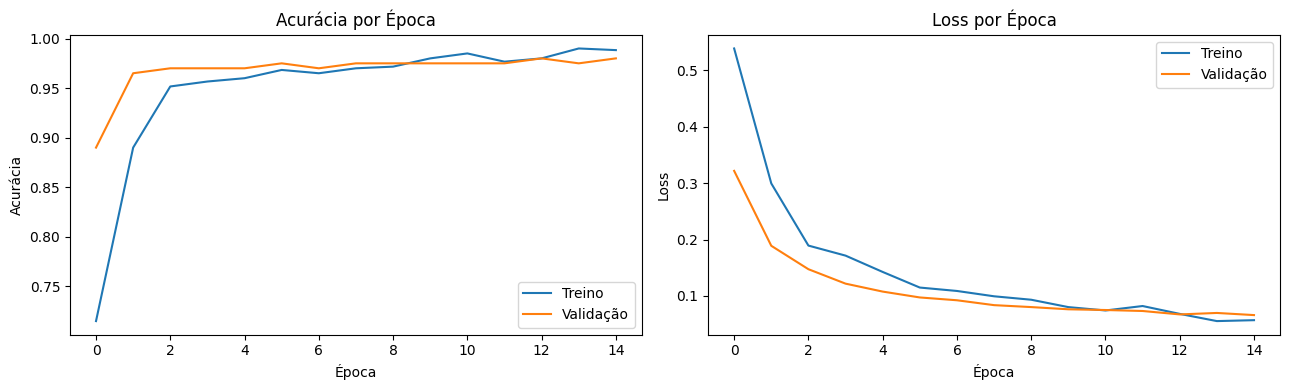

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["accuracy"],     label="Treino")
axes[0].plot(history.history["val_accuracy"], label="Validação")
axes[0].set_title("Acurácia por Época"); axes[0].set_xlabel("Época")
axes[0].set_ylabel("Acurácia"); axes[0].legend()

axes[1].plot(history.history["loss"],     label="Treino")
axes[1].plot(history.history["val_loss"], label="Validação")
axes[1].set_title("Loss por Época"); axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/figures/cnn_historico.png", dpi=150, bbox_inches="tight")
plt.show()


## Avaliação no Conjunto de Teste

              precision    recall  f1-score   support

   Fresh (0)       1.00      0.99      0.99       100
  Rotten (1)       0.99      1.00      1.00       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



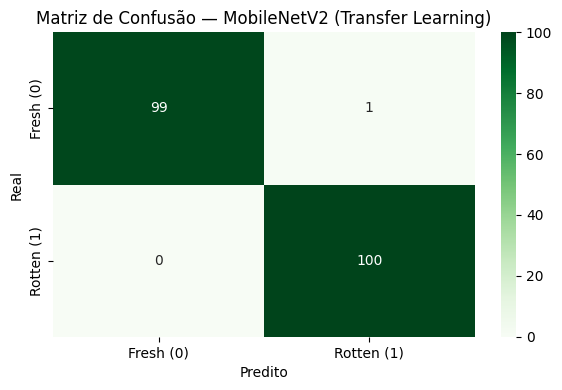

Acurácia CNN: 0.9950


In [8]:
probabilidades = model.predict(X_test_cnn, verbose=0)
y_pred_cnn     = (probabilidades > 0.5).astype(int).flatten()

nomes_classes = ["Fresh (0)", "Rotten (1)"]
print(classification_report(y_test, y_pred_cnn, target_names=nomes_classes))

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Greens",
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title("Matriz de Confusão — MobileNetV2 (Transfer Learning)")
plt.ylabel("Real"); plt.xlabel("Predito")
plt.tight_layout()
plt.savefig("../outputs/figures/matriz_confusao_cnn.png", dpi=300, bbox_inches="tight")
plt.show()

acc_cnn = accuracy_score(y_test, y_pred_cnn)
print(f"Acurácia CNN: {acc_cnn:.4f}")


## Comparação: Pipeline Clássico vs Transfer Learning

In [9]:
# Lê tabela do notebook 03
try:
    df_classicos = pd.read_csv("../outputs/tabela_comparativa.csv")
    melhor_classico = df_classicos.sort_values("F1", ascending=False).iloc[0]
    print("Melhor modelo clássico:")
    print(melhor_classico.to_string())
    print()
except FileNotFoundError:
    print("tabela_comparativa.csv não encontrado — execute o notebook 03 primeiro.")
    melhor_classico = None

print(f"CNN (MobileNetV2) — Acurácia Teste: {acc_cnn:.4f}")
print()
print("""
Comparação de custo/benefício:
┌─────────────────┬───────────────────────┬────────────────────────┐
│ Critério        │ Pipeline Clássico     │ Transfer Learning CNN  │
├─────────────────┼───────────────────────┼────────────────────────┤
│ Interpretável   │ ✓ (importância, SHAP) │ ✗ (caixa preta)        │
│ Custo treino    │ Baixo (segundos)      │ Alto (minutos/GPU)     │
│ Custo inferência│ Muito baixo           │ Médio                  │
│ Acurácia        │ Boa (features manuais)│ Muito boa (pixels raw) │
│ Dataset pequeno │ ✓ Funciona bem        │ Requer pré-treinamento │
└─────────────────┴───────────────────────┴────────────────────────┘
""")


Melhor modelo clássico:
Segmentação            GrabCut
Classificador    Random Forest
Val Acc                 0.9563
Test Acc                0.9375
Precisão                 0.973
Recall                     0.9
F1                      0.9351
AUC                     0.9884

CNN (MobileNetV2) — Acurácia Teste: 0.9950


Comparação de custo/benefício:
┌─────────────────┬───────────────────────┬────────────────────────┐
│ Critério        │ Pipeline Clássico     │ Transfer Learning CNN  │
├─────────────────┼───────────────────────┼────────────────────────┤
│ Interpretável   │ ✓ (importância, SHAP) │ ✗ (caixa preta)        │
│ Custo treino    │ Baixo (segundos)      │ Alto (minutos/GPU)     │
│ Custo inferência│ Muito baixo           │ Médio                  │
│ Acurácia        │ Boa (features manuais)│ Muito boa (pixels raw) │
│ Dataset pequeno │ ✓ Funciona bem        │ Requer pré-treinamento │
└─────────────────┴───────────────────────┴────────────────────────┘



## Salvando o Modelo CNN

In [10]:
model.save("../outputs/models/mobilenetv2_frutas.keras")
print("Modelo salvo em ../outputs/models/mobilenetv2_frutas.keras")


Modelo salvo em ../outputs/models/mobilenetv2_frutas.keras


## XAI — SHAP aplicado ao Random Forest Clássico

**Modelo analisado:** Random Forest treinado sobre features GrabCut (melhor modelo clássico).


Calculando SHAP values sobre 200 amostras...
sv2d shape: (200, 23), base_val: 0.4995


/tmp/ipykernel_54643/3703340016.py:32: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv2d, X_shap, show=False)


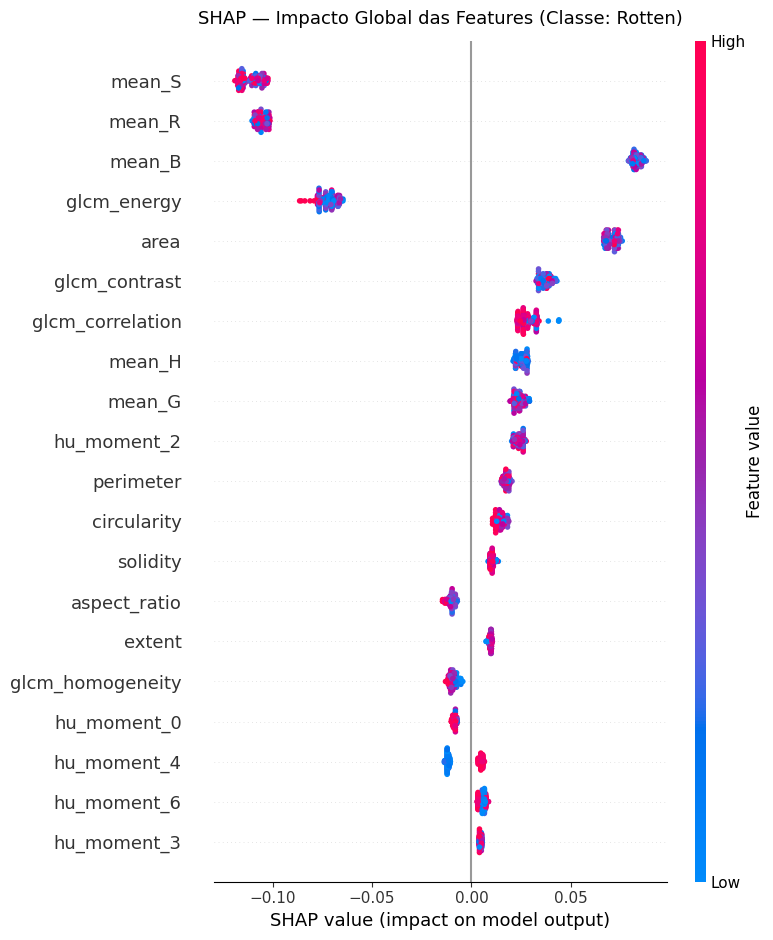

Explanation values shape: (23,)


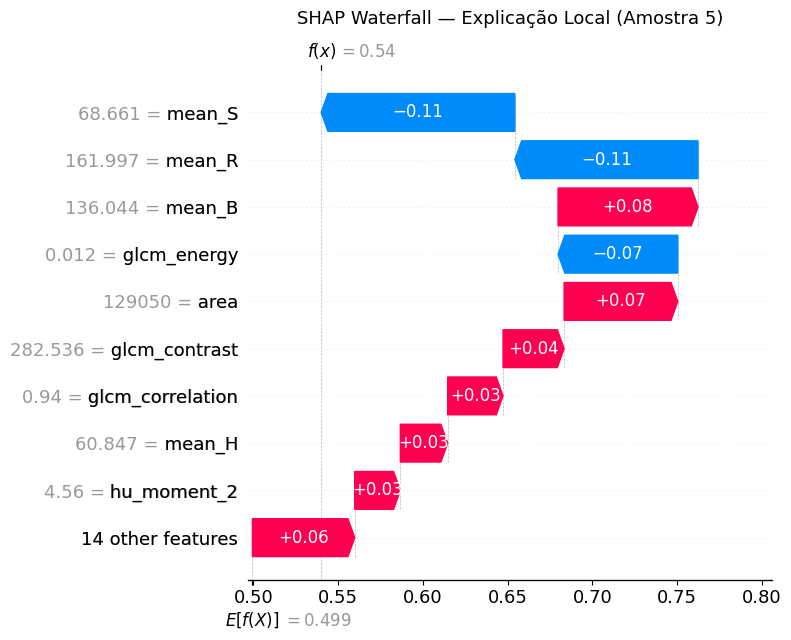

In [11]:
rf_model  = joblib.load("../outputs/models/rf_grabcut.pkl")
scaler    = joblib.load("../outputs/models/scaler_grabcut.pkl")
colunas   = joblib.load("../outputs/models/features_grabcut.pkl")

X_real = pd.read_csv("../outputs/X_grabcut.csv")
if "Unnamed: 0" in X_real.columns:
    X_real = X_real.drop(columns=["Unnamed: 0"])

SHAP_SAMPLE = min(200, len(X_real))
X_shap = X_real.sample(n=SHAP_SAMPLE, random_state=42).reset_index(drop=True)

print(f"Calculando SHAP values sobre {SHAP_SAMPLE} amostras...")
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    sv2d = shap_values[1]
elif shap_values.ndim == 3:
    sv2d = shap_values[:, :, 1]
else:
    sv2d = shap_values 

base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = float(base_val[1])
else:
    base_val = float(base_val)

print(f"sv2d shape: {sv2d.shape}, base_val: {base_val:.4f}")

plt.figure(figsize=(9, 7))
shap.summary_plot(sv2d, X_shap, show=False)
plt.title("SHAP — Impacto Global das Features (Classe: Rotten)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("../outputs/figures/shap_summary.png", dpi=200, bbox_inches="tight")
plt.show()

exp = shap.Explanation(
    values=sv2d[5],                  
    base_values=base_val,            
    data=X_shap.iloc[5].values,      
    feature_names=list(X_shap.columns),
)

print(f"Explanation values shape: {exp.values.shape}")

plt.figure(figsize=(9, 7))
shap.plots.waterfall(exp, show=False)
plt.title("SHAP Waterfall — Explicação Local (Amostra 5)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("../outputs/figures/shap_waterfall.png", dpi=200, bbox_inches="tight")
plt.show()


## Conclusão do Bônus

Como esperado, o modelo MobileNetV2 superou o nosso pipeline clássico em acurácia, aproveitando as representações que ele já aprendeu na ImageNet. Mas o mais interessante de todo o processo foi usar o SHAP no nosso modelo Random Forest clássico. Isso nos confirmou visualmente que o modelo não está 'roubando' através de ruídos no fundo da imagem, mas sim tomando decisões baseadas na cor e na textura da fruta, o que valida a nossa escolha de features manuais da etapa 2.
